# Кластеризация анекдотов anekdot.ru

Этот ноутбук собирает итоговую практическую часть в одном месте:
загрузку корпуса, разведочный анализ, визуализацию кластеров,
основные метрики, и дополнительные контрольные эксперименты.

Главный результат остается без учителя: Leiden-кластеризация по
текстовым признакам. Теги используются только для оценки и
отдельных контрольных моделей, где это явно указано.


In [1]:
from pathlib import Path
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import IFrame, Markdown, display

ROOT = Path.cwd()
if not (ROOT / "data").exists() and (ROOT.parent / "data").exists():
    ROOT = ROOT.parent

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 120)
print(f"Рабочая папка: {ROOT}")


Рабочая папка: C:\Users\user\Учёба\4 курс\Диплом Сони


## Воспроизводимый запуск

По умолчанию ноутбук читает уже сохраненные результаты, чтобы его
можно было быстро показать и прогнать. Если нужно пересобрать
артефакты, переключите `RUN_PIPELINE` на `True`. Тяжелый шаг с
эмбеддингами можно пропустить, если файлы уже есть.


In [2]:
RUN_PIPELINE = False

commands = [
    [sys.executable, "scripts/run_all.py", "--skip-existing"],
    [sys.executable, "scripts/13_hierarchical_evaluation.py"],
    [sys.executable, "scripts/14_supervised_tag_prediction_baseline.py"],
    [sys.executable, "scripts/15_semi_supervised_upper_bound.py"],
    [sys.executable, "scripts/16_final_evaluation_story.py"],
]

for cmd in commands:
    print(" ".join(cmd))
    if RUN_PIPELINE:
        subprocess.run(cmd, cwd=ROOT, check=True)


C:\Users\user\AppData\Local\Programs\Python\Python311\python.exe scripts/run_all.py --skip-existing
C:\Users\user\AppData\Local\Programs\Python\Python311\python.exe scripts/13_hierarchical_evaluation.py
C:\Users\user\AppData\Local\Programs\Python\Python311\python.exe scripts/14_supervised_tag_prediction_baseline.py
C:\Users\user\AppData\Local\Programs\Python\Python311\python.exe scripts/15_semi_supervised_upper_bound.py
C:\Users\user\AppData\Local\Programs\Python\Python311\python.exe scripts/16_final_evaluation_story.py


## Данные

Итоговый корпус содержит только записи, у которых на сайте есть
хотя бы один тег. Это важно: такие теги дают внешний источник
проверки качества без ручной построчной разметки анекдотов.


In [3]:
dataset = pd.read_csv(ROOT / "data/processed/anekdots_tagged.csv")
clustered = pd.read_csv(ROOT / "data/processed/anekdots_tagged_clustered.csv")
print(f"Строк в корпусе: {len(dataset):,}".replace(",", " "))
print(f"Период: {dataset['year'].min()}-{dataset['month'].min():02d} ... {dataset['year'].max()}-{dataset['month'].max():02d}")
print(f"Месяцев с данными: {dataset[['year', 'month']].drop_duplicates().shape[0]}")
print(f"Строк с тегами: {(dataset['tag_count'] >= 1).sum():,}".replace(",", " "))
display(dataset[["id", "year", "month", "text_clean", "tags_raw", "macro_tags"]].head(5))


Строк в корпусе: 5 509
Период: 1996-01 ... 2026-12
Месяцев с данными: 356
Строк с тегами: 5 509


,id,year,month,text_clean,tags_raw,macro_tags
0,-413100001,1996,1,"Лежит Пятачок, без глаза и без ноги . Походит Иа-Иа и спрашивает: - Что случилось , Пятачок ? - Да вот, поспорили с ...","[""Винни-Пух""]","[""literature_folklore_characters""]"
1,-413100002,1996,1,Наркоман поступил на работу в зоопарк. На следующий день ему поручили убрать клетку с черепахами. Вечером работники ...,"[""наркотики""]","[""alcohol_smoking_drugs""]"
2,-413000002,1996,1,"В троллейбус входит мужик с боксером(кобель). Малой лет четырех, указывая на собаку: - Мама, смотри какие шарики!","[""троллейбус""]","[""transport""]"
3,-413000003,1996,1,"Троллейбус. Утро. Батя, молоденький старлей, распекает ноющего сына. - Будешь хныкать - всем в детсадике расскажу чт...","[""троллейбус""]","[""transport""]"
4,-412800006,1996,1,"У одного мужика небыло чувства юмора, ну абсолютно. И родственники решили у него это чувство развить и собравшись ст...","[""юмор""]","[""absurd_philosophy""]"


## Разведочный анализ корпуса

Ниже показаны распределение по годам и самые частотные макро-теги.
Макро-теги нужны для оценки результата, но не добавляются в текст и
не используются как признаки основного кластерного алгоритма.


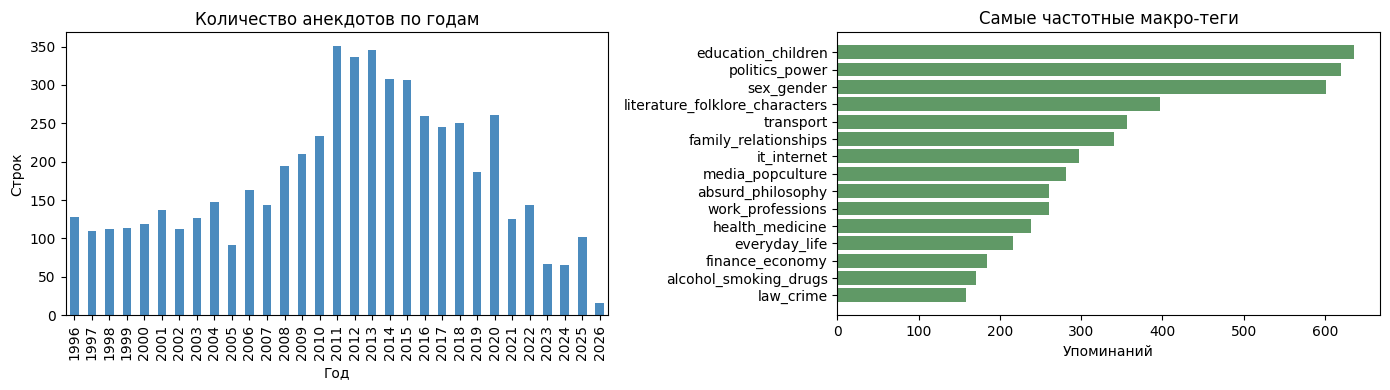

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
dataset["year"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color="#4b8bbe")
axes[0].set_title("Количество анекдотов по годам")
axes[0].set_xlabel("Год")
axes[0].set_ylabel("Строк")
axes[0].tick_params(axis="x", labelrotation=90)

top_macro = pd.read_csv(ROOT / "outputs/tables/top_macro_tags.csv").head(15)
axes[1].barh(top_macro["macro_tag"][::-1], top_macro["count"][::-1], color="#609966")
axes[1].set_title("Самые частотные макро-теги")
axes[1].set_xlabel("Упоминаний")
fig.tight_layout()
plt.show()


## Основная кластеризация

Главный результат: Leiden-кластеризация в гибридном текстовом
пространстве BGE/PCA + TF-IDF/SVD. Параметры финальной модели:
`k=75`, `resolution=2.0`, `seed=7`. Всего получилось 20 кластеров.


,method,feature_set,params,rows,cluster_count,largest_cluster_share,ari,ami,v_measure,pairwise_precision,pairwise_recall,pairwise_f1
12,leiden,hybrid_dense_lexical_dw0.75_lw0.25,k=75;resolution=2.0;seed=7,5509,20,0.129062,0.27684,0.377156,0.387097,0.351852,0.326731,0.338826


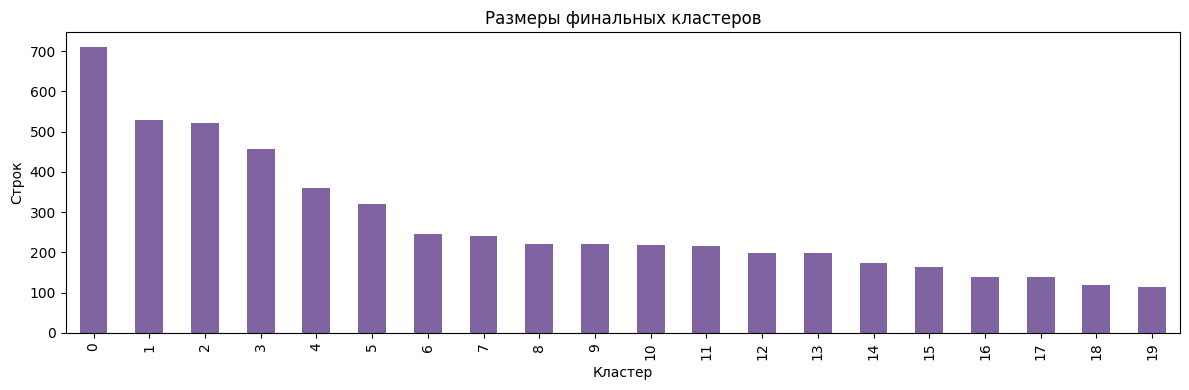

In [5]:
final_metrics = pd.read_csv(ROOT / "outputs/tables/final_metrics_summary.csv")
final_main = final_metrics[(final_metrics["model"] == "final") & (final_metrics["subset"] == "all")]
display(final_main[[
    "method", "feature_set", "params", "rows", "cluster_count",
    "largest_cluster_share", "ari", "ami", "v_measure",
    "pairwise_precision", "pairwise_recall", "pairwise_f1"
]])

sizes = pd.read_csv(ROOT / "outputs/tables/cluster_final_sizes.csv")
ax = sizes.sort_values("size", ascending=False).plot(
    x="cluster_final", y="size", kind="bar", figsize=(12, 4), legend=False, color="#8064a2"
)
ax.set_title("Размеры финальных кластеров")
ax.set_xlabel("Кластер")
ax.set_ylabel("Строк")
plt.tight_layout()
plt.show()


## Интерактивная карта UMAP

UMAP используется только для просмотра структуры, а не для обучения
кластеров. Если интерактивный блок не отображается в просмотрщике,
откройте файл `outputs/figures/umap3d_final.html`.


In [6]:
html_path = ROOT / "outputs/figures/umap3d_final.html"
display(IFrame(src=str(html_path), width="100%", height=620))


## Иерархическая оценка

Подробные макро-теги были дополнительно объединены в широкие
тематические группы первого уровня. Такая оценка обычно выше,
потому что она проверяет более грубое тематическое совпадение.


In [7]:
hierarchical = pd.read_csv(ROOT / "outputs/tables/hierarchical_metrics_summary.csv")
display(hierarchical[[
    "label_level", "subset", "rows", "label_count", "ari", "ami",
    "nmi", "homogeneity", "completeness", "v_measure", "pairwise_f1"
]])


,label_level,subset,rows,label_count,ari,ami,nmi,homogeneity,completeness,v_measure,pairwise_f1
0,level_1_broad,all,5509,7,0.169699,0.268966,0.272183,0.342003,0.226037,0.272183,0.247747
1,level_1_broad,single_clear_label,4993,7,0.188140,0.293314,0.296760,0.374484,0.245755,0.296760,0.264971
2,level_2_detailed,all,5509,27,0.276840,0.377156,0.387097,0.375376,0.399574,0.387097,0.338826
3,level_2_detailed,single_clear_label,4921,27,0.310480,0.409100,0.419784,0.408894,0.431270,0.419784,0.354086


## Контрольная модель с учителем

Эта модель не является кластеризацией. Она предсказывает макро-теги
по текстовым признакам на разбиении train/validation/test. Цель -
проверить, есть ли в тексте сигнал, связанный с тегами.


In [8]:
supervised = pd.read_csv(ROOT / "outputs/tables/supervised_tag_prediction_baseline.csv")
supervised_test = supervised[supervised["split"] == "test"].sort_values("micro_f1", ascending=False)
display(supervised_test[[
    "feature_set", "macro_f1", "micro_f1", "weighted_f1",
    "micro_precision", "micro_recall", "subset_accuracy"
]])


,feature_set,macro_f1,micro_f1,weighted_f1,micro_precision,micro_recall,subset_accuracy
0,hybrid_word_char_bge_pca,0.666485,0.725926,0.718051,0.751179,0.702315,0.672310
1,bge_pca128,0.608953,0.661756,0.654560,0.680653,0.643881,0.600967
2,tfidf_char_wb_3_5,0.576898,0.650144,0.638440,0.681159,0.621830,0.609432
3,tfidf_word_1_2,0.417648,0.536332,0.503704,0.562273,0.512679,0.498186


## Полуобучаемая верхняя граница

В этом эксперименте теги уже влияют на представление текстов:
создаются пары похожих и непохожих анекдотов, затем обучается
контрастивное преобразование эмбеддингов. Поэтому эти метрики нельзя
считать независимой проверкой основной кластеризации.


In [9]:
semi = pd.read_csv(ROOT / "outputs/tables/semi_supervised_embedding_metrics.csv")
display(semi[semi["selected"] == True][[
    "split", "params", "rows", "cluster_count", "ari", "ami",
    "v_measure", "pairwise_precision", "pairwise_recall", "pairwise_f1"
]])


,split,params,rows,cluster_count,ari,ami,v_measure,pairwise_precision,pairwise_recall,pairwise_f1
0,validation_selection,k=30;resolution=2.0;seed=42,1102,16,0.405547,0.427506,0.465997,0.442087,0.484783,0.462452
9,holdout,k=30;resolution=2.0;seed=42,1102,16,0.350148,0.389967,0.430929,0.401860,0.427146,0.414117
10,full_corpus_label_guided,k=30;resolution=2.0;seed=42,5509,16,0.402984,0.426672,0.434081,0.449204,0.478483,0.463381


## Итоговая картина метрик

В дипломе основной строкой следует считать независимую
unsupervised-кластеризацию. Остальные строки - вспомогательные:
они объясняют, почему грубые темы восстанавливаются лучше и почему
модели с использованием тегов дают отдельную, не независимую оценку.


In [10]:
story = pd.read_csv(ROOT / "outputs/tables/final_evaluation_story.csv")
display(story[[
    "display_name", "method_type", "evaluation_scope",
    "main_or_auxiliary", "independent_external_validation",
    "v_measure", "pairwise_f1", "macro_f1", "micro_f1", "note"
]])


,display_name,method_type,evaluation_scope,main_or_auxiliary,independent_external_validation,v_measure,pairwise_f1,macro_f1,micro_f1,note
0,Unsupervised Leiden final,unsupervised_clustering,"full corpus, level-2 detailed macro-tags",main,True,0.387097,0.338826,NaN,NaN,Primary result to report.
1,Unsupervised Leiden evaluated at level-1,hierarchical_evaluation,"full corpus, broad level-1 macro-tags",auxiliary,True,0.272183,0.247747,NaN,NaN,"Same clustering, broader evaluation target; not automatically higher."
2,Unsupervised Leiden evaluated at level-2,hierarchical_evaluation,"full corpus, detailed level-2 macro-tags",auxiliary,True,0.387097,0.338826,NaN,NaN,Should match detailed final validation except for hierarchy plumbing.
3,Supervised tag classifier,supervised_multilabel_classification,held-out test split,auxiliary_control,False,NaN,NaN,0.666485,0.725926,Best test feature set: hybrid_word_char_bge_pca. Not clustering.
4,Semi-supervised fine-tuned clustering holdout,semi_supervised_clustering_upper_bound,holdout split,auxiliary_upper_bound,False,0.430929,0.414117,NaN,NaN,Validation labels selected the representation/parameters; not independent.
5,Semi-supervised fine-tuned clustering full corpus,semi_supervised_clustering_upper_bound,"full corpus, label-guided",auxiliary_upper_bound,False,0.434081,0.463381,NaN,NaN,Full-corpus label-guided number for context only.


## Краткий вывод

Основная модель дает умеренные, но честные метрики: ARI около
0.277, V-measure около 0.387, точная pairwise F1 около 0.339.
Это ожидаемо для коротких юмористических текстов с несколькими
темами и шумными пользовательскими тегами. Иерархическая оценка
показывает согласование на более широких темах, а модели с
использованием тегов подтверждают, что теговый сигнал в тексте есть,
но они должны описываться отдельно от независимой кластеризации.
